A DataFrame is a two-dimensional, size-mutable, and potentially heterogeneous tabular data structure provided by the pandas library in Python. It is similar to a spreadsheet or SQL table, with labeled rows and columns, and is commonly used for data manipulation and analysis.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn import linear_model 

In [4]:
df = pd.read_csv("data/homeprices.csv")
df.head(3)

,area,price
0,2600,550000
1,3000,565000
2,3200,610000


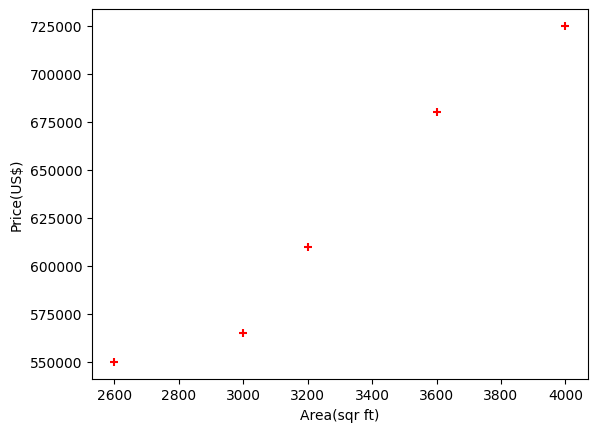

In [6]:
%matplotlib inline
plt.xlabel("Area(sqr ft)")
plt.ylabel("Price(US$)")
plt.scatter(df.area, df.price, color='red', marker='+')

In [7]:
reg = linear_model.LinearRegression()
reg.fit(df[['area']],df.price)
reg.predict([[3300]])

/Users/ashok/workspace/ml-basics/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([628715.75342466])

In [8]:
reg.coef_

array([135.78767123])

In [9]:
reg.intercept_

np.float64(180616.43835616432)

In [10]:
#Y = m*x+b
y = reg.coef_ * 3300 + reg.intercept_
y

array([628715.75342466])

In [11]:
d = pd.read_csv("data/areas.csv")
d.head(3)

,area
0,1000
1,1500
2,2300


In [12]:
p = reg.predict(d[['area']])

In [13]:
d['price'] = p
d.head(3)

,area,price
0,1000,316404.109589
1,1500,384297.945205
2,2300,492928.082192


In [14]:
d.to_csv("data/predicted_prices.csv", index=False)

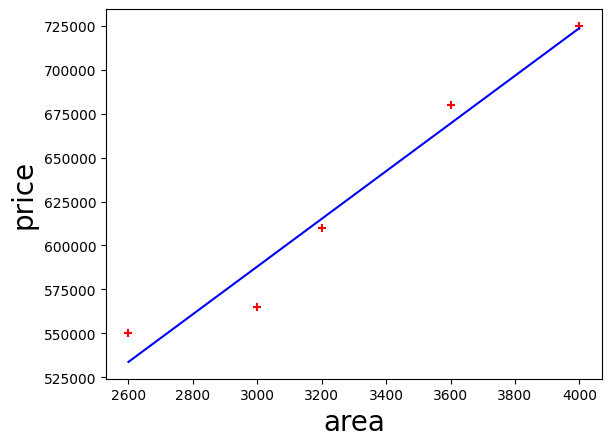

In [15]:
%matplotlib inline
plt.xlabel('area',fontsize=20)
plt.ylabel('price',fontsize=20)
plt.scatter(df.area, df.price, color='red', marker='+')
plt.plot(df.area, reg.predict(df[['area']]), color='blue')